# Isolation Forest - EAC Dataset Outlier Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from validator import validador, rules
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv("../dataFrames/data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (9984, 64)


,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,EMPAQUE,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
0,987664,4711-472,471-472,11.0,1986.0,0,603028,"112214,5",0,0,...,2409090,2499584,4837343,2454337,4837343,4837343,0,4980000,1110,5145586
1,987666,462,462-463,14.0,1996.0,0,1083695,77336,780,2970,...,3193,476400,4820346,"239796,5",4820346,4820346,0,4928292,1255,5288743
2,987667,4771-4751,476 - 477,4.0,1991.0,0,190661,26863,0,0,...,431759,422759,515488,427259,515488,515488,0,548094,16772,701070
3,987668,466,466-469,14.0,1986.0,0,2459238,"1262835,5",0,0,...,1963161,2694017,13114471,2328589,13114471,13114471,0,14487926,62938,14895893
4,987669,473,473,5.0,2004.0,0,1688361,"218895,5",0,0,...,141377,172460,7766200,"156918,5",7766200,7766200,0,8044113,57255,8847340


In [3]:
def parse_float(val):
    try:
        val = str(val).replace('.', '').replace(',', '.')
        return float(val)
    except ValueError:
        return np.nan

for col in df.columns:
    df[col] = df[col].apply(parse_float)

print(f"Data cleaned")

Data cleaned


In [4]:
business_variables = [
    'VENTA', 'BRUTA', 'CONSUI', 'AGREGA', 'CTO', 'CTOINS',
    'GASTOS', 'GAS', 'EMPAQUE', 'HONORA', 'COMISION', 'ARRIENDO', 
    'SEGURO', 'ENERGIA', 'FLETES', 'PUBLICI', 'OTROS',
    'TOTPERSO', 'PERREMUN', 'SUELDOS', 'PRESTAC', 'TOTREM',
    'INVINI', 'INVFIN', 'INVPRO', 'ROTACION'
]

available_vars = [var for var in business_variables if var in df.columns]
df_analysis = df[available_vars].copy()

missing_threshold = 0.3
df_analysis = df_analysis.dropna(thresh=int(len(available_vars) * (1 - missing_threshold)))
df_analysis = df_analysis.fillna(df_analysis.median())

print(f"Analysis dataset shape: {df_analysis.shape}")

Analysis dataset shape: (9984, 26)


In [5]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_analysis), 
    columns=df_analysis.columns,
    index=df_analysis.index
)
print("Data scaled")

Data scaled


In [6]:
contamination_rate = 0.05

isolation_forest = IsolationForest(
    contamination=contamination_rate,
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

outlier_labels = isolation_forest.fit_predict(df_scaled)
outlier_scores = isolation_forest.score_samples(df_scaled)

df_results = df_analysis.copy()
df_results['outlier_label'] = outlier_labels
df_results['outlier_score'] = outlier_scores
df_results['is_outlier'] = df_results['outlier_label'] == -1

n_outliers = (outlier_labels == -1).sum()
n_normal = (outlier_labels == 1).sum()

print(f"Total: {len(df_results)}")
print(f"Normal: {n_normal} ({n_normal/len(df_results)*100:.1f}%)")
print(f"Outliers: {n_outliers} ({n_outliers/len(df_results)*100:.1f}%)")

Total: 9984
Normal: 9484 (95.0%)
Outliers: 500 (5.0%)


## Compare with Business Rules

In [7]:
invalid_data = pd.read_csv("../dataFrames/invalidData.csv")

business_rule_violations = set(invalid_data.index)
isolation_outliers = set(df_results[df_results['is_outlier']].index)

overlap = business_rule_violations.intersection(isolation_outliers)
only_business_rules = business_rule_violations - isolation_outliers
only_isolation_forest = isolation_outliers - business_rule_violations

print(f"Business rule violations: {len(business_rule_violations)}")
print(f"Isolation Forest outliers: {len(isolation_outliers)}")
print(f"Overlap: {len(overlap)} ({len(overlap)/len(business_rule_violations)*100:.1f}%)")
print(f"Only in business rules: {len(only_business_rules)}")
print(f"Only in Isolation Forest: {len(only_isolation_forest)}")

Business rule violations: 221
Isolation Forest outliers: 500
Overlap: 5 (2.3%)
Only in business rules: 216
Only in Isolation Forest: 495


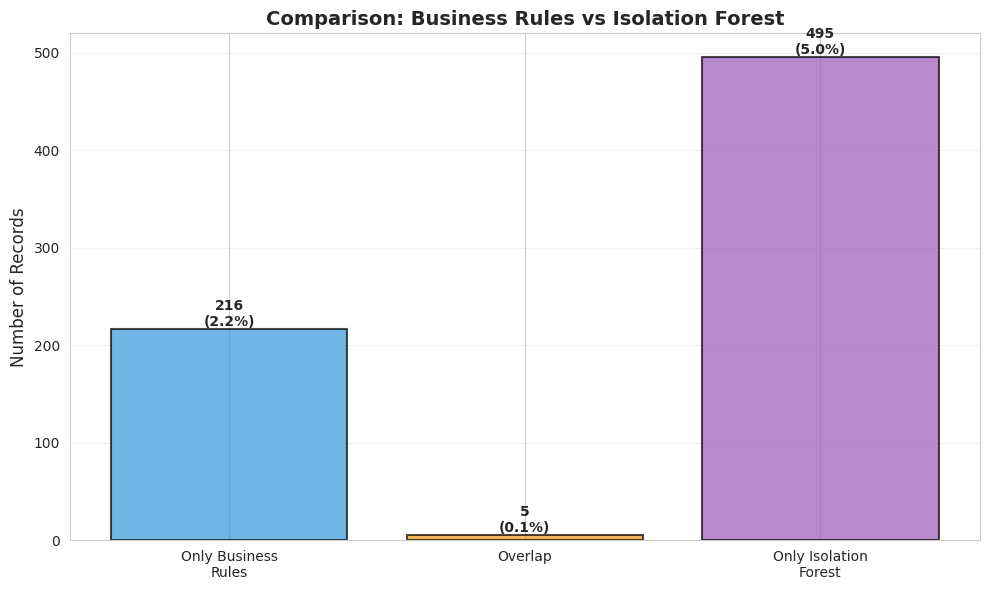

In [8]:
categories = ['Only Business\nRules', 'Overlap', 'Only Isolation\nForest']
values = [len(only_business_rules), len(overlap), len(only_isolation_forest)]
colors = ['#3498db', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.title('Comparison: Business Rules vs Isolation Forest', fontsize=14, fontweight='bold')
plt.ylabel('Number of Records', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{val}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

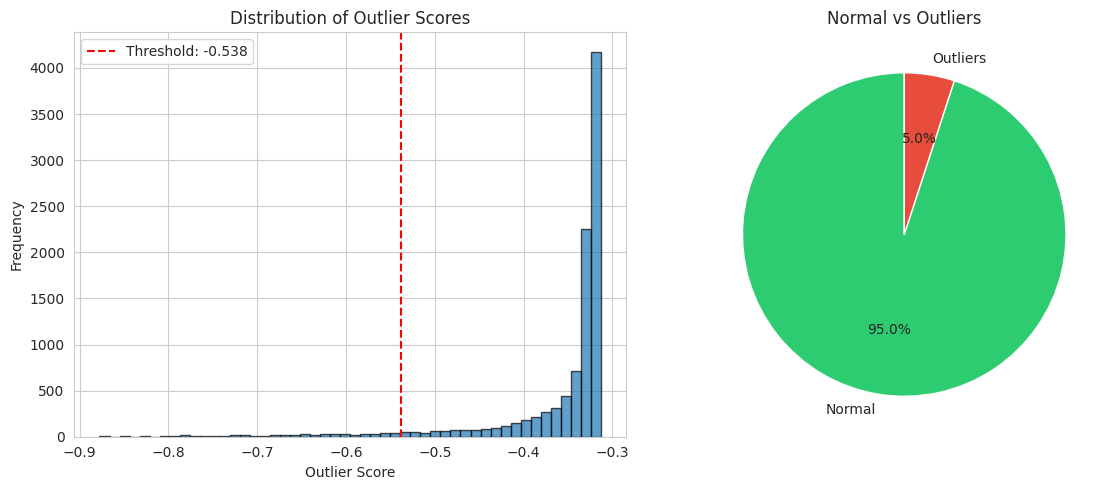

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(outlier_scores, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(outlier_scores[outlier_labels == -1].max(), color='red', linestyle='--', 
            label=f'Threshold: {outlier_scores[outlier_labels == -1].max():.3f}')
plt.xlabel('Outlier Score')
plt.ylabel('Frequency')
plt.title('Distribution of Outlier Scores')
plt.legend()

plt.subplot(1, 2, 2)
labels = ['Normal', 'Outliers']
sizes = [n_normal, n_outliers]
colors = ['#2ecc71', '#e74c3c']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Normal vs Outliers')

plt.tight_layout()
plt.show()

In [10]:
outliers_df = df.loc[df_results[df_results['is_outlier']].index].copy()
outliers_df['outlier_score'] = df_results[df_results['is_outlier']]['outlier_score'].values

results = validador(outliers_df, rules)
print("Validation results on Isolation Forest outliers:")
print(results)

Validation results on Isolation Forest outliers:
                   regla  cantidad_invalidos  porcentaje_invalidos
0                  nulos                   0                   0.0
1       venta_produccion                   0                   0.0
2     produccion_consumo                   3                   0.6
3         valor_agregado                  33                   6.6
4                 costos                   0                   0.0
5             eficiencia                   0                   0.0
6    margen_val_agregado                   3                   0.6
7    consistencia_gastos                   0                   0.0
8      proporcion_ventas                   6                   1.2
9   peso_relativo_gastos                   1                   0.2
10    rentabilidad_bruta                   0                   0.0


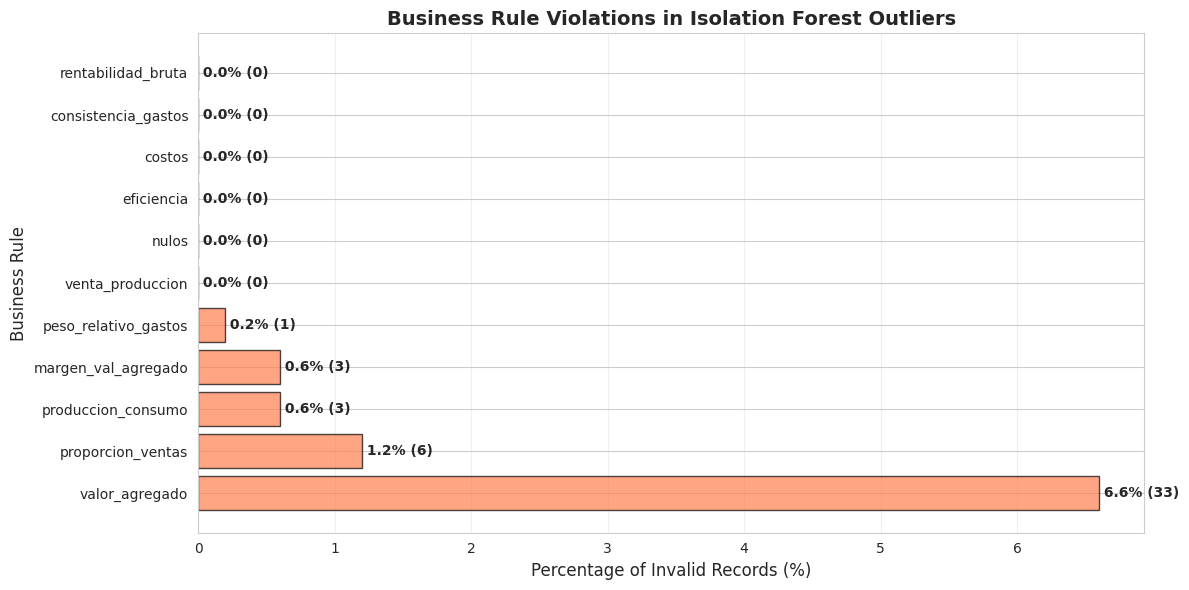

In [11]:
plt.figure(figsize=(12, 6))
results_sorted = results.sort_values('porcentaje_invalidos', ascending=False)

bars = plt.barh(results_sorted['regla'], results_sorted['porcentaje_invalidos'], 
                color='coral', alpha=0.7, edgecolor='black')
plt.xlabel('Percentage of Invalid Records (%)', fontsize=12)
plt.ylabel('Business Rule', fontsize=12)
plt.title('Business Rule Violations in Isolation Forest Outliers', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(results_sorted.iterrows()):
    plt.text(row['porcentaje_invalidos'], i, 
             f" {row['porcentaje_invalidos']:.1f}% ({row['cantidad_invalidos']})", 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Export Results

In [12]:
outlier_results = df_results[df_results['is_outlier']].copy()
outlier_results = outlier_results.sort_values('outlier_score')
outlier_results.to_csv("../dataFrames/isolation_forest_outliers.csv", index=True)

print(f"Exported {len(outlier_results)} outliers")
print(f"Score range: {outlier_scores.min():.4f} to {outlier_scores.max():.4f}")

Exported 500 outliers
Score range: -0.8776 to -0.3130
